# 01 - Mismo esquema, pero apuntando a una galaxia real

Este notebook repite A+B+C, pero el punto `(z, y, x)` se obtiene desde el `truth catalogue`:

1. Se lee una fuente real con RA, Dec y frecuencia central.
2. Se convierte a píxeles con WCS.
3. Se genera:
   - **A)** matriz 10x10 en el plano `z_galaxy`.
   - **B)** la misma matriz con valores float.
   - **C)** perfil de 10 canales en `z` para el píxel `(y_galaxy, x_galaxy)`.


In [ ]:
from pathlib import Path
import os
import warnings

import numpy as np
import pandas as pd
from astropy.io import fits
from astropy.io.fits.verify import VerifyWarning
from astropy.wcs import WCS, FITSFixedWarning

warnings.simplefilter("ignore", VerifyWarning)
warnings.simplefilter("ignore", FITSFixedWarning)


def find_project_root() -> Path:
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "data" / "sky_dev_v2.fits").exists():
            return candidate
    raise FileNotFoundError("No se ha encontrado data/sky_dev_v2.fits. Ajusta FITS_PATH.")


PROJECT_ROOT = find_project_root()
STEP_ROOT = PROJECT_ROOT / "demo" / "paso1"
TABLES_DIR = STEP_ROOT / "tables"
TABLES_DIR.mkdir(parents=True, exist_ok=True)

os.environ.setdefault("MPLCONFIGDIR", str(STEP_ROOT / ".matplotlib"))
(STEP_ROOT / ".matplotlib").mkdir(parents=True, exist_ok=True)
import matplotlib.pyplot as plt

FITS_PATH = PROJECT_ROOT / "data" / "sky_dev_v2.fits"
TRUTH_PATH = PROJECT_ROOT / "data" / "sky_dev_truthcat_v2.txt"

FIGURES_DIR = STEP_ROOT / "figures" / "01_truth_galaxy"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
print(f"FIGURES_DIR: {FIGURES_DIR}")
print(f"TABLES_DIR: {TABLES_DIR}")


FIGURES_DIR: /home/willy/sdc2/demo/paso1/figures/01_truth_galaxy
TABLES_DIR: /home/willy/sdc2/demo/paso1/tables


In [ ]:
def require_file(path: Path, label: str) -> Path:
    if not path.exists():
        raise FileNotFoundError(f"No se ha encontrado {path}. Ajusta {label}.")
    return path


def open_fits_cube(path: Path):
    """Abre el FITS con memmap=True. No carga el cubo entero en RAM."""
    require_file(path, "FITS_PATH")
    hdul = fits.open(path, memmap=True)
    hdu = next((item for item in hdul if item.data is not None), None)
    if hdu is None:
        hdul.close()
        raise ValueError(f"El FITS no contiene datos: {path}")
    data = np.squeeze(hdu.data)
    if data.ndim != 3:
        hdul.close()
        raise ValueError(f"Se esperaba un cubo 3D tras squeeze(), pero shape={data.shape}")
    return hdul, data, hdu.header


def percentile_limits(values, low=5, high=95):
    finite = np.asarray(values)[np.isfinite(values)]
    if finite.size == 0:
        return None, None
    vmin, vmax = np.nanpercentile(finite, [low, high])
    if np.isclose(vmin, vmax):
        return None, None
    return float(vmin), float(vmax)


def centered_start(center: int, size: int, max_size: int) -> int:
    return int(np.clip(center - size // 2, 0, max_size - size))


def save_figure(fig, path: Path, dpi=160):
    path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(path, dpi=dpi, bbox_inches="tight", facecolor="white")
    print(f"Figura guardada: {path}")


def matrix_dataframe(matrix, y0_global, x0_global):
    return pd.DataFrame(
        [[f"{float(matrix[i, j]):.3e}" for j in range(matrix.shape[1])] for i in range(matrix.shape[0])],
        index=[f"y={y0_global + i}" for i in range(matrix.shape[0])],
        columns=[f"x={x0_global + j}" for j in range(matrix.shape[1])],
    )


def plot_a_patch(matrix10, selected_local_y, selected_local_x, selected_global_zyx, selected_value, output_path, title):
    vmin, vmax = percentile_limits(matrix10, 5, 95)
    fig, ax = plt.subplots(figsize=(4.2, 4.0), facecolor="white")
    ax.imshow(matrix10, origin="upper", cmap="gray", vmin=vmin, vmax=vmax, interpolation="nearest")
    ax.set_title(title)
    ax.set_xlabel("x local")
    ax.set_ylabel("y local")
    z, y, x = selected_global_zyx
    ax.text(
        0.03, 0.97,
        f"pixel elegido\nz,y,x=({z},{y},{x})\nI={selected_value:.2e}",
        transform=ax.transAxes, va="top", ha="left", fontsize=8,
        bbox={"facecolor": "white", "edgecolor": "black", "alpha": 0.78, "pad": 3},
    )
    save_figure(fig, output_path)
    plt.show()


def plot_b_values(matrix10, selected_local_y, selected_local_x, output_path, title):
    vmin, vmax = percentile_limits(matrix10, 5, 95)
    threshold = np.nanmean(matrix10)
    fig, ax = plt.subplots(figsize=(5.2, 5.0), facecolor="white")
    ax.imshow(matrix10, origin="upper", cmap="gray", vmin=vmin, vmax=vmax, interpolation="nearest")
    ax.set_title(title)
    ax.set_xlabel("x local")
    ax.set_ylabel("y local")
    ax.set_xticks(np.arange(matrix10.shape[1]))
    ax.set_yticks(np.arange(matrix10.shape[0]))
    ax.tick_params(labelsize=7)
    for local_y in range(matrix10.shape[0]):
        for local_x in range(matrix10.shape[1]):
            value = float(matrix10[local_y, local_x])
            color = "white" if value < threshold else "black"
            ax.text(local_x, local_y, f"{value:.1e}", ha="center", va="center", fontsize=5.5, color=color)
    save_figure(fig, output_path)
    plt.show()


def plot_c_profile(z_values, profile, z_selected, selected_global_yx, output_path, title):
    fig, ax = plt.subplots(figsize=(5.4, 2.9), facecolor="white")
    ax.plot(z_values, profile, color="black", lw=1.3, marker="o", markersize=3)
    ax.axvline(z_selected, color="0.35", lw=1.0, linestyle="--")
    y, x = selected_global_yx
    ax.set_title(title)
    ax.set_xlabel("z")
    ax.set_ylabel("intensidad")
    ax.grid(alpha=0.22, color="0.7")
    ax.text(
        0.03, 0.95,
        f"pixel fijo: y={y}, x={x}\nz central={z_selected}",
        transform=ax.transAxes, va="top", ha="left", fontsize=8,
        bbox={"facecolor": "white", "edgecolor": "black", "alpha": 0.75, "pad": 3},
    )
    save_figure(fig, output_path)
    plt.show()


def plot_summary(matrix10, selected_local_y, selected_local_x, z_values, profile, z_selected, output_path, title):
    vmin, vmax = percentile_limits(matrix10, 5, 95)
    threshold = np.nanmean(matrix10)
    fig, axes = plt.subplots(1, 3, figsize=(12, 3.6), facecolor="white")

    axes[0].imshow(matrix10, origin="upper", cmap="gray", vmin=vmin, vmax=vmax, interpolation="nearest")
    axes[0].set_title("A) matriz 10x10")
    axes[0].set_xlabel("x local")
    axes[0].set_ylabel("y local")

    axes[1].imshow(matrix10, origin="upper", cmap="gray", vmin=vmin, vmax=vmax, interpolation="nearest")
    axes[1].set_title("B) valores")
    axes[1].set_xticks(np.arange(matrix10.shape[1]))
    axes[1].set_yticks(np.arange(matrix10.shape[0]))
    axes[1].tick_params(labelsize=6)
    for local_y in range(matrix10.shape[0]):
        for local_x in range(matrix10.shape[1]):
            value = float(matrix10[local_y, local_x])
            color = "white" if value < threshold else "black"
            axes[1].text(local_x, local_y, f"{value:.1e}", ha="center", va="center", fontsize=4.8, color=color)

    axes[2].plot(z_values, profile, color="black", lw=1.3, marker="o", markersize=3)
    axes[2].axvline(z_selected, color="0.35", lw=1.0, linestyle="--")
    axes[2].set_title("C) perfil z")
    axes[2].set_xlabel("z")
    axes[2].set_ylabel("intensidad")
    axes[2].grid(alpha=0.22, color="0.7")

    fig.suptitle(title, fontsize=12)
    fig.tight_layout()
    save_figure(fig, output_path)
    plt.show()


## Elegir una fuente real del truth catalogue

Por defecto seleccionamos automáticamente una fuente fuerte y lejos de los bordes para que la matriz 10x10 quede bien centrada. Si quieres forzar una fuente concreta, cambia `MANUAL_TRUTH_ROW`.


In [ ]:
def read_truth(path: Path) -> pd.DataFrame:
    require_file(path, "TRUTH_PATH")
    return pd.read_csv(path, sep=r"\s+", engine="python", comment="#")


def truth_to_pixel_table(truth: pd.DataFrame, header, cube_shape) -> pd.DataFrame:
    wcs = WCS(header)
    rows = []
    for idx, row in truth.iterrows():
        try:
            x_raw, y_raw, z_raw = wcs.all_world2pix(float(row["ra"]), float(row["dec"]), float(row["central_freq"]), 0)
            x_pix, y_pix, z_pix = [float(np.asarray(v).squeeze()) for v in (x_raw, y_raw, z_raw)]
        except Exception:
            continue
        if 0 <= z_pix < cube_shape[0] and 0 <= y_pix < cube_shape[1] and 0 <= x_pix < cube_shape[2]:
            edge_dist = min(x_pix, y_pix, cube_shape[2] - 1 - x_pix, cube_shape[1] - 1 - y_pix)
            rows.append({
                "truth_row": idx,
                "id": row.get("id", idx),
                "ra": row["ra"],
                "dec": row["dec"],
                "central_freq": row["central_freq"],
                "line_flux_integral": row.get("line_flux_integral", np.nan),
                "hi_size": row.get("hi_size", np.nan),
                "w20": row.get("w20", np.nan),
                "x_pix": x_pix,
                "y_pix": y_pix,
                "z_pix": z_pix,
                "x": int(round(x_pix)),
                "y": int(round(y_pix)),
                "z": int(round(z_pix)),
                "edge_dist": edge_dist,
            })
    out = pd.DataFrame(rows)
    out["visual_score"] = out["line_flux_integral"].fillna(0) * np.sqrt(out["hi_size"].fillna(1))
    return out


hdul, data, header = open_fits_cube(FITS_PATH)
truth = read_truth(TRUTH_PATH)
truth_pixels = truth_to_pixel_table(truth, header, data.shape)

MANUAL_TRUTH_ROW = None
if MANUAL_TRUTH_ROW is None:
    candidates = truth_pixels[truth_pixels["edge_dist"] >= 6].sort_values("visual_score", ascending=False)
    selected = candidates.iloc[0]
else:
    selected = truth_pixels[truth_pixels["truth_row"] == MANUAL_TRUTH_ROW].iloc[0]

z_selected = int(selected["z"])
y_selected = int(selected["y"])
x_selected = int(selected["x"])
selected_value = float(data[z_selected, y_selected, x_selected])

print("Fuente seleccionada del truth catalogue")
print(f"truth_row: {int(selected['truth_row'])}")
print(f"id: {selected['id']}")
print(f"RA, Dec, freq: {selected['ra']}, {selected['dec']}, {selected['central_freq']}")
print(f"pixel global z,y,x = ({z_selected}, {y_selected}, {x_selected})")
print(f"valor central = {selected_value:.8g}")
display(truth_pixels.sort_values("visual_score", ascending=False).head(10))


Fuente seleccionada del truth catalogue
truth_row: 701
id: 701.0
RA, Dec, freq: 180.26791381835935, -29.983800888061523, 1108079232.0
pixel global z,y,x = (5269, 341, 23)
valor central = 5.5713866e-05


,truth_row,id,ra,dec,central_freq,line_flux_integral,hi_size,w20,x_pix,y_pix,z_pix,x,y,z,edge_dist,visual_score
701,701,701.0,180.267914,-29.983801,1.108079e+09,566.674776,35.730545,798.491176,22.640754,341.478648,5269.307733,23,341,5269,22.640754,3387.300306
226,226,226.0,179.794891,-29.908550,1.122020e+09,446.579490,39.778779,513.491308,549.590197,438.373606,5734.007467,550,438,5734,92.409803,2816.595619
225,225,225.0,179.829376,-30.031677,1.122636e+09,265.688808,29.419231,406.166993,510.922011,280.130720,5754.521600,511,280,5755,131.077989,1441.082744
700,700,700.0,180.160721,-29.927469,1.109079e+09,243.962909,30.949242,377.271966,141.913177,414.128202,5302.647467,142,414,5303,141.913177,1357.215501
698,698,698.0,180.205261,-29.874109,1.101165e+09,176.294665,35.994679,748.249527,92.160689,482.654429,5038.830933,92,483,5039,92.160689,1057.689818
224,224,224.0,180.097717,-29.801001,1.114165e+09,188.575711,25.097466,380.987019,211.978121,576.809379,5472.174933,212,577,5472,65.190621,944.714737
223,223,223.0,179.789749,-30.131210,1.123033e+09,183.807202,24.361359,353.122961,554.795511,152.086673,5767.778133,555,152,5768,87.204489,907.221383
222,222,222.0,180.250214,-29.967220,1.126809e+09,174.387077,24.579566,367.886060,42.305737,362.841050,5893.632000,42,363,5894,42.305737,864.572480
219,219,219.0,180.032364,-30.012861,1.145571e+09,166.802952,23.810587,337.745289,284.968734,304.459017,6519.027200,285,304,6519,284.968734,813.933245
220,220,220.0,179.894272,-30.101883,1.137563e+09,166.260925,23.512187,395.471062,438.603082,189.953471,6252.104533,439,190,6252,189.953471,806.188693


## A+B+C alrededor de la galaxia

La matriz y el perfil se construyen con el mismo punto de referencia de la fuente real.


In [ ]:
MATRIX_SIZE = 10
Z_PROFILE_SIZE = 10

matrix_y0 = centered_start(y_selected, MATRIX_SIZE, data.shape[1])
matrix_x0 = centered_start(x_selected, MATRIX_SIZE, data.shape[2])
matrix10 = np.asarray(data[z_selected, matrix_y0:matrix_y0 + MATRIX_SIZE, matrix_x0:matrix_x0 + MATRIX_SIZE], dtype=np.float32)

# La fuente del truth catalogue nos da z0 y una posición aproximada.
truth_local_y = y_selected - matrix_y0
truth_local_x = x_selected - matrix_x0

# Para seguir visualmente la "mancha positiva" de B_galaxy,
# tomamos el máximo positivo dentro de la matriz 10x10 en z0.
spot_local_y, spot_local_x = [int(v) for v in np.unravel_index(np.nanargmax(matrix10), matrix10.shape)]
spot_global_y = matrix_y0 + spot_local_y
spot_global_x = matrix_x0 + spot_local_x
spot_value = float(data[z_selected, spot_global_y, spot_global_x])

# Desde aquí, el punto marcado en A/B/C/D es la mancha positiva.
local_y = spot_local_y
local_x = spot_local_x
y_profile = spot_global_y
x_profile = spot_global_x
selected_value = spot_value

z_start = centered_start(z_selected, Z_PROFILE_SIZE, data.shape[0])
z_stop = z_start + Z_PROFILE_SIZE
z_values = np.arange(z_start, z_stop)
profile10 = np.asarray(data[z_start:z_stop, y_profile, x_profile], dtype=np.float32)

print(f"z0 de la galaxia según truth/WCS: z_selected = {z_selected}")
print(f"Matriz A/B: cube[{z_selected}, {matrix_y0}:{matrix_y0 + MATRIX_SIZE}, {matrix_x0}:{matrix_x0 + MATRIX_SIZE}]")
print(f"Punto aproximado del truth en la matriz: local y,x=({truth_local_y}, {truth_local_x}); global y,x=({y_selected}, {x_selected})")
print(f"Mancha positiva elegida en B: local y,x=({local_y}, {local_x}); global y,x=({y_profile}, {x_profile})")
print(f"Valor máximo positivo en z0: cube[{z_selected}, {y_profile}, {x_profile}] = {selected_value:.8g}")
print(f"Perfil C de esa mancha: cube[{z_start}:{z_stop}, {y_profile}, {x_profile}]")


z0 de la galaxia según truth/WCS: z_selected = 5269
Matriz A/B: cube[5269, 336:346, 18:28]
Punto aproximado del truth en la matriz: local y,x=(5, 5); global y,x=(341, 23)
Mancha positiva elegida en B: local y,x=(4, 1); global y,x=(340, 19)
Valor máximo positivo en z0: cube[5269, 340, 19] = 5.9370221e-05
Perfil C de esa mancha: cube[5264:5274, 340, 19]


Figura guardada: /home/willy/sdc2/demo/paso1/figures/01_truth_galaxy/A_galaxy_matrix_10x10_gray.png


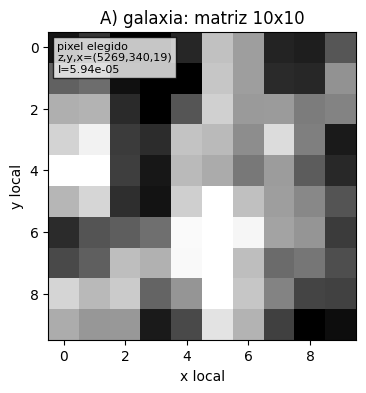

Figura guardada: /home/willy/sdc2/demo/paso1/figures/01_truth_galaxy/B_galaxy_matrix_10x10_values.png


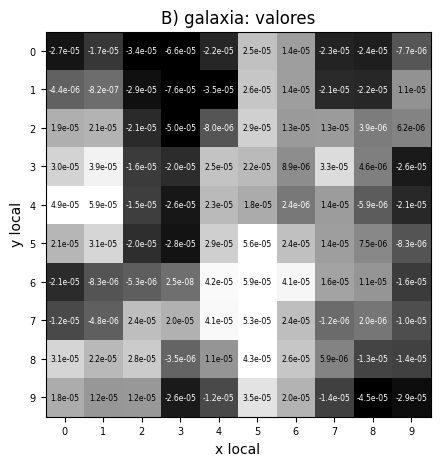

,x=18,x=19,x=20,x=21,x=22,x=23,x=24,x=25,x=26,x=27
y=336,-2.725e-05,-1.708e-05,-3.366e-05,-6.579e-05,-2.199e-05,2.472e-05,1.413e-05,-2.313e-05,-2.446e-05,-7.709e-06
y=337,-4.425e-06,-8.182e-07,-2.865e-05,-7.562e-05,-3.466e-05,2.612e-05,1.417e-05,-2.102e-05,-2.181e-05,1.051e-05
y=338,1.904e-05,2.057e-05,-2.077e-05,-5.007e-05,-8.020e-06,2.919e-05,1.297e-05,1.309e-05,3.882e-06,6.204e-06
y=339,3.023e-05,3.926e-05,-1.587e-05,-2.003e-05,2.503e-05,2.246e-05,8.932e-06,3.282e-05,4.613e-06,-2.583e-05
y=340,4.907e-05,5.937e-05,-1.493e-05,-2.648e-05,2.259e-05,1.793e-05,2.442e-06,1.358e-05,-5.900e-06,-2.134e-05
y=341,2.140e-05,3.104e-05,-1.980e-05,-2.776e-05,2.886e-05,5.571e-05,2.419e-05,1.398e-05,7.526e-06,-8.259e-06
y=342,-2.058e-05,-8.309e-06,-5.274e-06,2.508e-08,4.163e-05,5.920e-05,4.051e-05,1.583e-05,1.131e-05,-1.579e-05
y=343,-1.172e-05,-4.802e-06,2.372e-05,1.972e-05,4.149e-05,5.341e-05,2.355e-05,-1.203e-06,2.014e-06,-1.018e-05
y=344,3.069e-05,2.206e-05,2.751e-05,-3.510e-06,1.146e-05,4.310e-05,2.596e-05,5.916e-06,-1.299e-05,-1.369e-05
y=345,1.835e-05,1.183e-05,1.225e-05,-2.563e-05,-1.161e-05,3.492e-05,2.039e-05,-1.437e-05,-4.530e-05,-2.950e-05


Tabla guardada: /home/willy/sdc2/demo/paso1/tables/01_galaxy_matrix_10x10_values.csv
Figura guardada: /home/willy/sdc2/demo/paso1/figures/01_truth_galaxy/C_galaxy_profile_z_10_channels.png


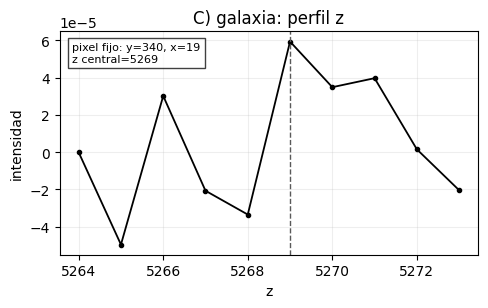

,z,y,x,intensity
0,5264,340,19,-7.385674e-08
1,5265,340,19,-4.958746e-05
2,5266,340,19,3.018503e-05
3,5267,340,19,-2.070344e-05
4,5268,340,19,-3.347663e-05
5,5269,340,19,5.937022e-05
6,5270,340,19,3.488602e-05
7,5271,340,19,3.971859e-05
8,5272,340,19,1.544764e-06
9,5273,340,19,-2.040996e-05


Tabla guardada: /home/willy/sdc2/demo/paso1/tables/01_galaxy_profile_z_10_channels.csv
Figura guardada: /home/willy/sdc2/demo/paso1/figures/01_truth_galaxy/ABC_galaxy_summary.png


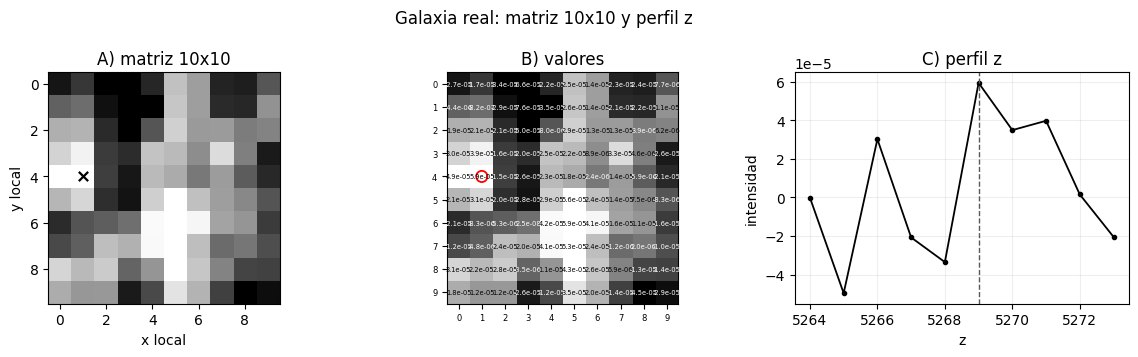

In [ ]:
plot_a_patch(
    matrix10, local_y, local_x,
    (z_selected, y_profile, x_profile), selected_value,
    FIGURES_DIR / "A_galaxy_matrix_10x10_gray.png",
    "A) galaxia: matriz 10x10",
)

plot_b_values(
    matrix10, local_y, local_x,
    FIGURES_DIR / "B_galaxy_matrix_10x10_values.png",
    "B) galaxia: valores",
)

matrix_df = matrix_dataframe(matrix10, matrix_y0, matrix_x0)
display(matrix_df)
matrix_df.to_csv(TABLES_DIR / "01_galaxy_matrix_10x10_values.csv")
print(f"Tabla guardada: {TABLES_DIR / '01_galaxy_matrix_10x10_values.csv'}")

plot_c_profile(
    z_values, profile10, z_selected, (y_profile, x_profile),
    FIGURES_DIR / "C_galaxy_profile_z_10_channels.png",
    "C) galaxia: perfil z",
)

profile_df = pd.DataFrame({"z": z_values, "y": y_profile, "x": x_profile, "intensity": profile10})
display(profile_df)
profile_df.to_csv(TABLES_DIR / "01_galaxy_profile_z_10_channels.csv", index=False)
print(f"Tabla guardada: {TABLES_DIR / '01_galaxy_profile_z_10_channels.csv'}")

plot_summary(
    matrix10, local_y, local_x, z_values, profile10, z_selected,
    FIGURES_DIR / "ABC_galaxy_summary.png",
    "Galaxia real: matriz 10x10 y perfil z",
)


## Evolución en z de la misma región espacial

Ahora mantenemos exactamente los mismos píxeles espaciales de la matriz 10x10 (`y` y `x` fijos) y mostramos 9 canales `z` alrededor de la frecuencia central de la galaxia.

Esto sirve para explicar que una galaxia HI no es una única imagen 2D: aparece como una estructura que evoluciona a lo largo del eje espectral.


Correspondencia verificada
A/B usan z_selected = 5269
Panel +0 de la evolución usa z = 5269
Mancha positiva marcada en todas las imágenes: local y,x=(4, 1); global y,x=(340, 19)
Misma ventana espacial: y=336:346, x=18:28
Figura guardada: /home/willy/sdc2/demo/paso1/figures/01_truth_galaxy/D_galaxy_z_evolution_9_slices.png


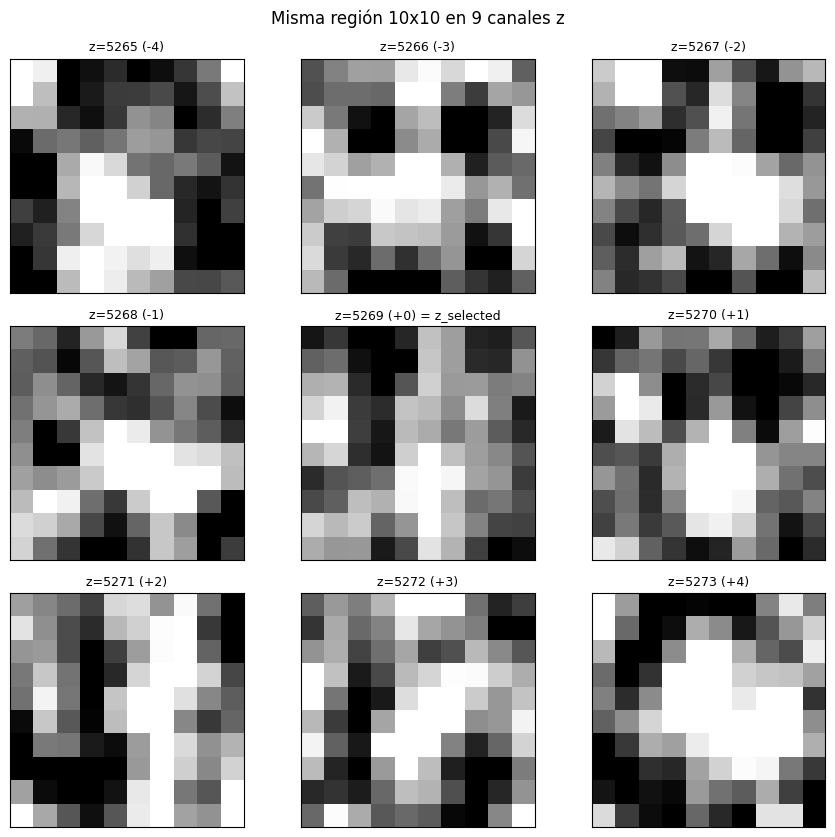

Figura guardada: /home/willy/sdc2/demo/paso1/figures/01_truth_galaxy/D_galaxy_z_slice_-4.png
Figura guardada: /home/willy/sdc2/demo/paso1/figures/01_truth_galaxy/D_galaxy_z_slice_-3.png
Figura guardada: /home/willy/sdc2/demo/paso1/figures/01_truth_galaxy/D_galaxy_z_slice_-2.png
Figura guardada: /home/willy/sdc2/demo/paso1/figures/01_truth_galaxy/D_galaxy_z_slice_-1.png
Figura guardada: /home/willy/sdc2/demo/paso1/figures/01_truth_galaxy/D_galaxy_z_slice_+0.png
Figura guardada: /home/willy/sdc2/demo/paso1/figures/01_truth_galaxy/D_galaxy_z_slice_+1.png
Figura guardada: /home/willy/sdc2/demo/paso1/figures/01_truth_galaxy/D_galaxy_z_slice_+2.png
Figura guardada: /home/willy/sdc2/demo/paso1/figures/01_truth_galaxy/D_galaxy_z_slice_+3.png
Figura guardada: /home/willy/sdc2/demo/paso1/figures/01_truth_galaxy/D_galaxy_z_slice_+4.png


,z,offset_from_selected_z,y_spot,x_spot,spot_intensity
0,5265,-4,340,19,-0.000050
1,5266,-3,340,19,0.000030
2,5267,-2,340,19,-0.000021
3,5268,-1,340,19,-0.000033
4,5269,0,340,19,0.000059
5,5270,1,340,19,0.000035
6,5271,2,340,19,0.000040
7,5272,3,340,19,0.000002
8,5273,4,340,19,-0.000020


Tabla guardada: /home/willy/sdc2/demo/paso1/tables/01_galaxy_positive_spot_evolution.csv


,z,offset_from_selected_z,y_start,y_stop,x_start,x_stop
0,5265,-4,336,346,18,28
1,5266,-3,336,346,18,28
2,5267,-2,336,346,18,28
3,5268,-1,336,346,18,28
4,5269,0,336,346,18,28
5,5270,1,336,346,18,28
6,5271,2,336,346,18,28
7,5272,3,336,346,18,28
8,5273,4,336,346,18,28


Tabla guardada: /home/willy/sdc2/demo/paso1/tables/01_galaxy_z_evolution_slices.csv


In [ ]:
# 9 canales alrededor de z_selected, manteniendo la misma ventana espacial 10x10.
Z_EVOLUTION_OFFSETS = np.array([-4, -3, -2, -1, 0, 1, 2, 3, 4])
z_evolution = np.clip(z_selected + Z_EVOLUTION_OFFSETS, 0, data.shape[0] - 1).astype(int)

# Comprobación de correspondencia: el canal central (+0) debe ser el mismo z_selected
# usado en A/B, y la X marcada es el mismo pixel local en todas las matrices.
center_idx = int(np.where(Z_EVOLUTION_OFFSETS == 0)[0][0])
assert int(z_evolution[center_idx]) == int(z_selected)
print("Correspondencia verificada")
print(f"A/B usan z_selected = {z_selected}")
print(f"Panel +0 de la evolución usa z = {z_evolution[center_idx]}")
print(f"Mancha positiva marcada en todas las imágenes: local y,x=({local_y}, {local_x}); global y,x=({y_profile}, {x_profile})")
print(f"Misma ventana espacial: y={matrix_y0}:{matrix_y0 + MATRIX_SIZE}, x={matrix_x0}:{matrix_x0 + MATRIX_SIZE}")

# Leemos solo un pequeño bloque: 9 matrices de 10x10, no el cubo completo.
evolution_stack = np.asarray(
    [data[z, matrix_y0:matrix_y0 + MATRIX_SIZE, matrix_x0:matrix_x0 + MATRIX_SIZE] for z in z_evolution],
    dtype=np.float32,
)
assert np.allclose(evolution_stack[center_idx], matrix10, equal_nan=True)

# Usamos exactamente la misma escala de grises que A/B.
# Así el panel +0 se ve igual que la matriz original sin valores.
vmin_evo, vmax_evo = percentile_limits(matrix10, 5, 95)

fig, axes = plt.subplots(3, 3, figsize=(9, 8.5), facecolor="white")
axes = axes.ravel()
for ax, z, offset, image in zip(axes, z_evolution, Z_EVOLUTION_OFFSETS, evolution_stack):
    ax.imshow(image, origin="upper", cmap="gray", vmin=vmin_evo, vmax=vmax_evo, interpolation="nearest")
    ax.set_title(f"z={z} ({offset:+d})" + (" = z_selected" if offset == 0 else ""), fontsize=9)
    ax.set_xticks([])
    ax.set_yticks([])

fig.suptitle("Misma región 10x10 en 9 canales z", fontsize=12)
fig.tight_layout()
save_figure(fig, FIGURES_DIR / "D_galaxy_z_evolution_9_slices.png")
plt.show()

# También guardamos cada canal por separado por si quieres usarlos como capturas individuales.
for z, offset, image in zip(z_evolution, Z_EVOLUTION_OFFSETS, evolution_stack):
    fig, ax = plt.subplots(figsize=(3.2, 3.0), facecolor="white")
    ax.imshow(image, origin="upper", cmap="gray", vmin=vmin_evo, vmax=vmax_evo, interpolation="nearest")
    ax.set_title(f"z={z} ({offset:+d})" + (" = z_selected" if offset == 0 else ""))
    ax.set_xlabel("x local")
    ax.set_ylabel("y local")
    save_figure(fig, FIGURES_DIR / f"D_galaxy_z_slice_{offset:+d}.png")
    plt.close(fig)

spot_values = evolution_stack[:, local_y, local_x]
spot_evolution_df = pd.DataFrame({"z": z_evolution, "offset_from_selected_z": Z_EVOLUTION_OFFSETS, "y_spot": y_profile, "x_spot": x_profile, "spot_intensity": spot_values})
display(spot_evolution_df)
spot_evolution_df.to_csv(TABLES_DIR / "01_galaxy_positive_spot_evolution.csv", index=False)
print(f"Tabla guardada: {TABLES_DIR / '01_galaxy_positive_spot_evolution.csv'}")

z_evolution_df = pd.DataFrame({
    "z": z_evolution,
    "offset_from_selected_z": Z_EVOLUTION_OFFSETS,
    "y_start": matrix_y0,
    "y_stop": matrix_y0 + MATRIX_SIZE,
    "x_start": matrix_x0,
    "x_stop": matrix_x0 + MATRIX_SIZE,
})
display(z_evolution_df)
z_evolution_df.to_csv(TABLES_DIR / "01_galaxy_z_evolution_slices.csv", index=False)
print(f"Tabla guardada: {TABLES_DIR / '01_galaxy_z_evolution_slices.csv'}")


In [ ]:
hdul.close()
